In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input,
    decode_predictions
)

model = MobileNetV2(weights='imagenet')

print("Model loaded successfully!")

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model loaded successfully!


In [3]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
        const div = document.createElement('div');

        const video = document.createElement('video');
        video.style.display = 'block';

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;

        await video.play();

        await new Promise((resolve) => {
            const button = document.createElement('button');
            button.textContent = 'Take Photo';
            div.appendChild(button);
            button.onclick = () => resolve();
        });

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getVideoTracks()[0].stop();
        div.remove();

        return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

filename = take_photo()
print("Photo saved:", filename)

<IPython.core.display.Javascript object>

Photo saved: photo.jpg


In [5]:
from tensorflow.keras.utils import load_img, img_to_array

# بارگذاری عکس گرفته‌شده
img = load_img(filename, target_size=(224, 224))

# تبدیل عکس به آرایه
img_array = img_to_array(img)

# اضافه کردن بعد Batch
img_array = np.expand_dims(img_array, axis=0)

# پیش‌پردازش مخصوص MobileNetV2
img_array = preprocess_input(img_array)

print("Image shape:", img_array.shape)

Image shape: (1, 224, 224, 3)


In [6]:
predictions = model.predict(img_array)

results = decode_predictions(predictions, top=5)[0]

for _, label, probability in results:
    print(f"{label}: {probability * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
water_bottle: 96.39%
pop_bottle: 0.80%
water_jug: 0.65%
nipple: 0.25%
beaker: 0.13%


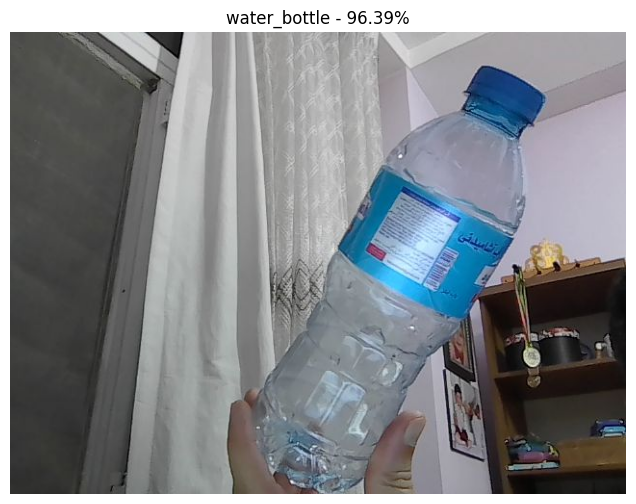

In [7]:
import matplotlib.pyplot as plt

# محتمل‌ترین تشخیص
_, label, probability = results[0]

# نمایش تصویر
plt.figure(figsize=(8, 6))
plt.imshow(load_img(filename))
plt.axis('off')

# نوشتن نام شیء و درصد اطمینان
plt.title(f"{label} - {probability * 100:.2f}%")

plt.show()